In [8]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import ccf
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [3]:
IN = '../data/raw'
OUT = '../data/python_master'

df = pd.read_csv(f"{IN}/planning_applications/PS2_data_-_open_data_table__202512_.csv",
                  encoding="cp1252", skiprows=2)

# list_cols = df.columns.to_list()
# for col in list_cols:
#     if "Total granted" in col:
#         print(col)

# Columns we need: Total granted; major total (all), Total granted; minor total(all)

df['Total_Granted'] = df["Total granted; major total (all)"]

qs = df['Quarter'].str.replace(" ", "")
df['Quarter'] = pd.PeriodIndex(qs, freq='Q')

# Groupping by quarter then summing for England total- may revisit file later on for regional analysis
df_eng = df.groupby('Quarter')['Total_Granted'].sum().reset_index()

df_eng.to_csv(f"{OUT}/planning/plan_granted.csv")

/tmp/ipykernel_18531/3720993600.py:4: DtypeWarning: Columns (0: Total decisions; major dwellings (all), 1: Total granted; major dwellings (all), 2: Total refused; major dwellings (all), 3: Total decided within 8 weeks; major dwellings (excluding PAs), 4: Total decided within 8 to 13 weeks; major dwellings (excluding PAs), 5: Total decided within 13 to 16 weeks; major dwellings (excluding PAs), 6: Total decided within 16 to 26 weeks; major dwellings (excluding PAs), 7: Total decided within 26 to 52 weeks; major dwellings (excluding PAs), 8: Total decided beyond 52 weeks; major dwellings (excluding PAs), 9: Total decided within maximum time; major dwellings (excluding PAs), 10: Total decisions; major dwellings (PAs only), 11: Total decisions in time; major dwellings (PAs only), 12: Total decisions; major offices R&D light industry (all), 13: Total granted; major offices R&D light industry (all), 14: Total refused; major offices R&D light industry (all), 15: Total decided within 8 weeks; 

<Axes: xlabel='Quarter'>

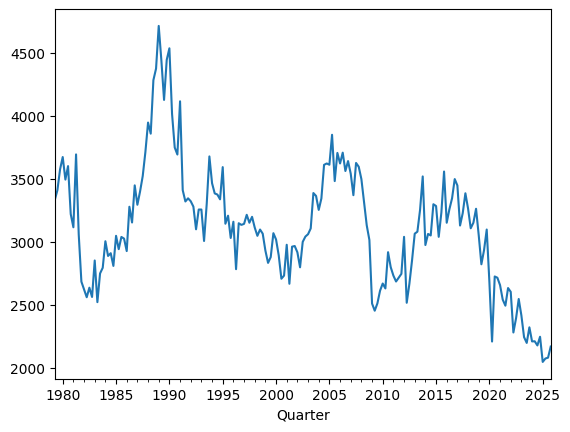

In [4]:
df_eng.set_index('Quarter')['Total_Granted'].plot()

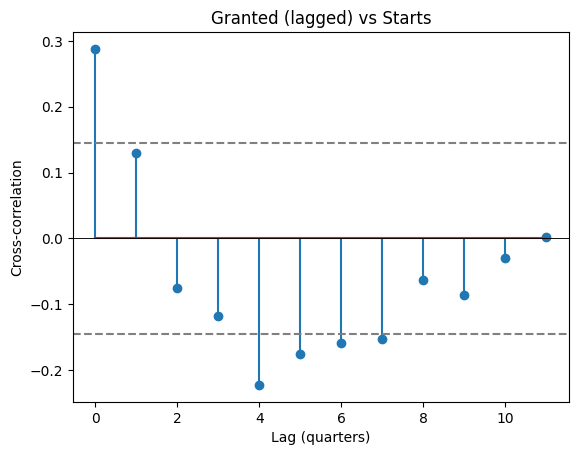

,Quarter,Starts,Total_Granted,dTotal_Granted_SA,dStarts_SA
4,1980Q2,25210.0,3494,164.0,-8090.0
5,1980Q3,20120.0,3601,192.0,-14140.0
6,1980Q4,17500.0,3220,-355.0,-17010.0
7,1981Q1,22790.0,3115,-558.0,2320.0
8,1981Q2,27720.0,3694,200.0,2510.0


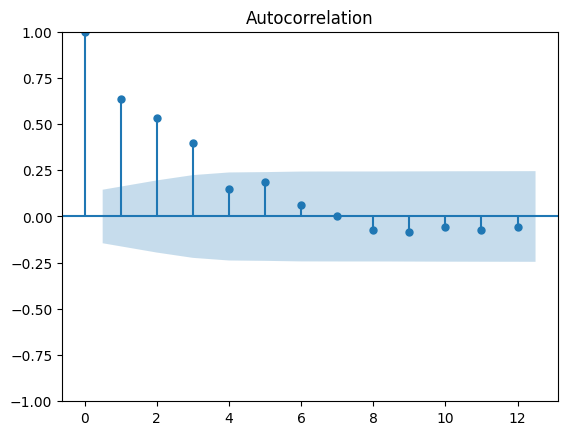

In [12]:
df_starts = pd.read_csv(f"{OUT}/england_master.csv")

df_starts = df_starts.iloc[:,:2]

df_starts.columns = ['Quarter', 'Starts']

df_starts['Quarter'] = pd.PeriodIndex(df_starts['Quarter'], freq='Q')


df = pd.merge(df_starts, df_eng, on='Quarter')

df

# Starts was found to be trend stationary I(0), but we choose to difference so we dont compare level-diff
#  We convert total granted to I(0) by differencing adjusting for seasonality
df['dTotal_Granted_SA'] = df['Total_Granted'].diff(4)
df['dStarts_SA'] = df['Starts'].diff(4)
df = df.dropna()

# Finding cross correlations across lags
result = ccf(df['dStarts_SA'], df['dTotal_Granted_SA'])

n_lags = 12

n = len(df)
conf = 1.96 / np.sqrt(n)

plt.stem(range(n_lags), result[:n_lags])
plt.axhline(0, color='black', linewidth=0.5)
plt.axhline(conf, color='gray', linestyle='--')
plt.axhline(-conf, color='gray', linestyle='--')
plt.xlabel('Lag (quarters)')
plt.ylabel('Cross-correlation')
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Granted (lagged) vs Starts')
plt.show()

# Co-movement with 0-1 quarter - we choose 1

# Checking ACF of Total Granted
plot_acf(df['dTotal_Granted_SA'].dropna(), lags=12)
df.head()

In [15]:
df['dStarts_SA_lag1'] = df['dStarts_SA'].shift(1)

# Model A: AR(1) only
X_a = sm.add_constant(df[['dStarts_SA_lag1']])
model_a = sm.OLS(df['dStarts_SA'], X_a, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags':4})

# Model B: AR(1) + permissions lag
df['dGranted_SA_lag1'] = df['dTotal_Granted_SA'].shift(1)
X_b = sm.add_constant(df[['dStarts_SA_lag1', 'dGranted_SA_lag1']])
model_b = sm.OLS(df['dStarts_SA'], X_b, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags':4})

print(model_a.summary())
print(model_b.summary())

                            OLS Regression Results                            
Dep. Variable:             dStarts_SA   R-squared:                       0.368
Model:                            OLS   Adj. R-squared:                  0.364
Method:                 Least Squares   F-statistic:                     40.21
Date:                Fri, 12 Jun 2026   Prob (F-statistic):           1.78e-09
Time:                        15:58:38   Log-Likelihood:                -1830.6
No. Observations:                 182   AIC:                             3665.
Df Residuals:                     180   BIC:                             3672.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               3.7203    418.419     